In [1]:
from pathlib import Path
import json
import pandas as pd

# Path to your folder
#TODO: !!!!change folder name to the model you are analyzing!!!!!!!!!!!!
folder = Path("../eval/artifacts/gemini-2.0-flash")

rows = []
for p in folder.glob("*_metrics.json"):
    stem = p.stem  # filename without suffix
    tgt_lang = stem.rsplit("_metrics", 1)[0]

    with p.open("r", encoding="utf-8") as fh:
        data = json.load(fh)
        row = {
            "tgt_lang": tgt_lang,
            "overall_success": data.get("overall_success"),
            "knowledge_transfer": data.get("transfer"),
            "n_QA": data.get("n_items"),  # adjusted to match JSON key
        }
        rows.append(row)

# Convert to DataFrame
df = pd.DataFrame(rows)
print(df)

   tgt_lang  overall_success  knowledge_transfer  n_QA
0        ko         0.333333            0.464286    39
1        it         0.512821            0.714286    39
2        zh         0.461538            0.642857    39
3        hi         0.384615            0.535714    39
4        he         0.282051            0.392857    39
5        ja         0.487179            0.678571    39
6        id         0.512821            0.714286    39
7        es         0.538462            0.750000    39
8        pt         0.564103            0.785714    39
9        fr         0.589744            0.821429    39
10       de         0.487179            0.678571    39


In [2]:
df.to_csv(folder / "all_metrics_summary.csv", index=False)

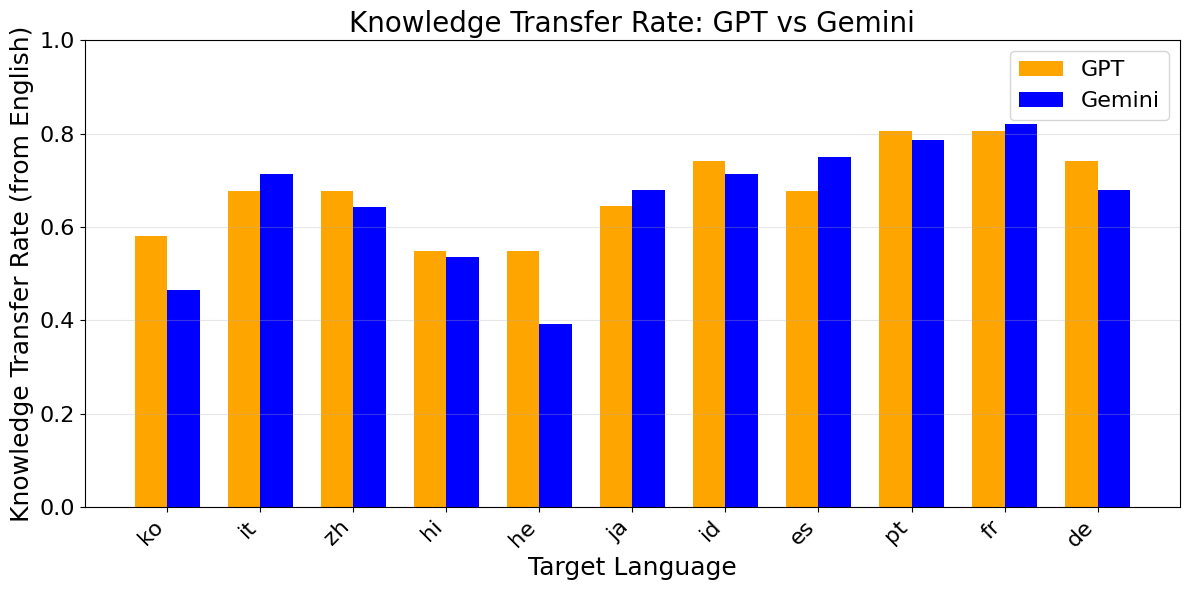

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ================================
# 1. Load the two result tables
# ================================
# Each CSV should have columns:
# tgt_lang, overall_success, knowledge_transfer, n_QA

gpt_path = Path("../eval/artifacts/gpt-4o/all_metrics_summary.csv")
gemini_path = Path("../eval/artifacts/gemini-2.0-flash/all_metrics_summary.csv")

df_gpt = pd.read_csv(gpt_path)
df_gemini = pd.read_csv(gemini_path)

# ================================
# 2. Merge on tgt_lang
# ================================
df = df_gpt.merge(
    df_gemini,
    on="tgt_lang",
    suffixes=("_gpt", "_gemini")
)

# Optional: keep a specific language order
# (here we keep the GPT file order)
languages = df["tgt_lang"].tolist()

# X positions
x = np.arange(len(languages))
width = 0.35  # width of each bar

# ================================
# 3. Plot grouped bar chart
# ================================
plt.figure(figsize=(12, 6))

# GPT – orange
plt.bar(
    x - width/2,
    df["knowledge_transfer_gpt"],
    width=width,
    label="GPT",
    color="orange"
)

# Gemini – blue
plt.bar(
    x + width/2,
    df["knowledge_transfer_gemini"],
    width=width,
    label="Gemini",
    color="blue"
)

# ================================
# 4. Formatting
# ================================
plt.xticks(x, languages, rotation=45, ha="right", fontsize=16)
plt.yticks(fontsize=16)

plt.ylabel("Knowledge Transfer Rate (from English)", fontsize=18)
plt.xlabel("Target Language", fontsize=18)
plt.title("Knowledge Transfer Rate: GPT vs Gemini", fontsize=20)

plt.legend(fontsize=16)
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 1.0)

plt.tight_layout()
plt.show()